In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/urban-segmentation-isprs/complexscenes_revision_v4.pdf
/kaggle/input/urban-segmentation-isprs/Toronto/Images/03747.tif
/kaggle/input/urban-segmentation-isprs/Toronto/Images/03749.tif
/kaggle/input/urban-segmentation-isprs/Toronto/Images/03947.tif
/kaggle/input/urban-segmentation-isprs/Toronto/Images/03949.tif
/kaggle/input/urban-segmentation-isprs/Toronto/Images/03945.tif
/kaggle/input/urban-segmentation-isprs/Toronto/Images/03755.tif
/kaggle/input/urban-segmentation-isprs/Toronto/Images/03751.tif
/kaggle/input/urban-segmentation-isprs/Toronto/Images/03555.tif
/kaggle/input/urban-segmentation-isprs/Toronto/Images/03559.tif
/kaggle/input/urban-segmentation-isprs/Toronto/Images/03757.tif
/kaggle/input/urban-segmentation-isprs/Toronto/Images/03557.tif
/kaggle/input/urban-segmentation-isprs/Toronto/Images/03753.tif
/kaggle/input/urban-segmentation-isprs/Toronto/Images/03553.tif
/kaggle/input/urban-segmentation-isprs/Vaihingen/Labels/top_mosaic_09cm_area8.tif
/kaggle/input/urb

In [2]:
import os

# --- CORRECT CONFIGURATION ---
DATA_ROOT = "/kaggle/input/urban-segmentation-isprs/Potsdam"

# Use the exact names you found: 'Images' and 'Labels'
IMAGE_DIR = os.path.join(DATA_ROOT, "Images")
MASK_DIR = os.path.join(DATA_ROOT, "Labels")

# Verify immediately
if os.path.exists(IMAGE_DIR):
    print(f"✅ SUCCESS! Found Images at: {IMAGE_DIR}")
    print(f"   Count: {len(os.listdir(IMAGE_DIR))} files")
else:
    print(f"❌ Error: Could not find {IMAGE_DIR}")

if os.path.exists(MASK_DIR):
    print(f"✅ SUCCESS! Found Masks at: {MASK_DIR}")
    print(f"   Count: {len(os.listdir(MASK_DIR))} files")
else:
    print(f"❌ Error: Could not find {MASK_DIR}")

✅ SUCCESS! Found Images at: /kaggle/input/urban-segmentation-isprs/Potsdam/Images
   Count: 38 files
✅ SUCCESS! Found Masks at: /kaggle/input/urban-segmentation-isprs/Potsdam/Labels
   Count: 38 files


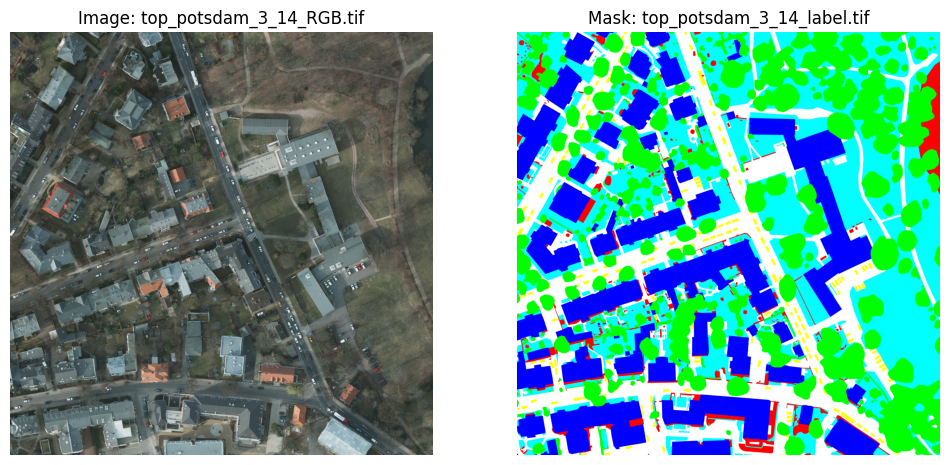

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

# 1. Pick an image
test_filename = os.listdir(IMAGE_DIR)[0] # e.g., top_potsdam_2_10_RGB.tif

# 2. Define the paths
img_path = os.path.join(IMAGE_DIR, test_filename)

# --- THE FIX IS HERE ---
# We replace "_RGB" with "_label" to find the matching mask
mask_filename = test_filename.replace("_RGB", "_label") 
mask_path = os.path.join(MASK_DIR, mask_filename)

# 3. Load them
image = Image.open(img_path)
mask = Image.open(mask_path)

# 4. Visualize
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title(f"Image: {test_filename}")
ax[0].axis('off')

ax[1].imshow(mask)
ax[1].set_title(f"Mask: {mask_filename}")
ax[1].axis('off')

plt.show()

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import os
from torchvision import transforms

# 1. DEFINE THE TRANSLATION KEY (The Colormap)
# This maps the RGB color to a Class ID (0-5)
VOC_COLORMAP = [
    [255, 255, 255], # 0: Impervious (Roads) -> White
    [0, 0, 255],     # 1: Building -> Blue
    [0, 255, 255],   # 2: Low Veg -> Cyan
    [0, 255, 0],     # 3: Tree -> Green
    [255, 255, 0],   # 4: Car -> Yellow
    [255, 0, 0]      # 5: Clutter -> Red
]

# 2. CREATE THE DATASET CLASS
class PotsdamDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(image_dir)) # List all image names

    def __len__(self):
        return len(self.images)

    def rgb_to_label(self, mask_rgb):
        """
        This function takes an RGB mask (Height x Width x 3)
        and converts it into a Label mask (Height x Width x 1)
        where every pixel is a number 0-5.
        """
        # Create a blank mask of zeros
        mask_label = np.zeros((mask_rgb.shape[0], mask_rgb.shape[1]), dtype=np.longlong)
        
        # Check every pixel against our color map
        for id, color in enumerate(VOC_COLORMAP):
            # Find pixels that match this color
            matches = np.all(mask_rgb == color, axis=-1)
            # Set those pixels to the ID number
            mask_label[matches] = id
            
        return mask_label

    def __getitem__(self, idx):
        # A. Load File Names
        img_name = self.images[idx]
        # Remember the fix: replace _RGB with _label for the mask!
        mask_name = img_name.replace("_RGB", "_label")
        
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        # B. Open Images
        image = np.array(Image.open(img_path).convert("RGB"))
        mask_rgb = np.array(Image.open(mask_path).convert("RGB"))

        # C. Translate Mask (The Magic Step)
        mask_label = self.rgb_to_label(mask_rgb)
        
        # D. Convert to PyTorch Tensor format
        # Images need to be (Channels, Height, Width) and 0.0-1.0
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        # Masks just need to be Long Integers
        mask = torch.from_numpy(mask_label).long()
        
        # E. Resize (Optional but recommended for speed)
        # Large images crash the GPU. Let's resize to 256x256 for now.
        resize = transforms.Resize((256, 256))
        image = resize(image)
        # Use Nearest Neighbor for masks so we don't invent new "colors"
        mask = transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST)(mask.unsqueeze(0)).squeeze(0)

        return image, mask

# 3. TEST IT
# Let's see if it works!
dataset = PotsdamDataset(IMAGE_DIR, MASK_DIR)
test_img, test_mask = dataset[0]

print(f"Image Shape: {test_img.shape}") # Should be [3, 256, 256]
print(f"Mask Shape:  {test_mask.shape}") # Should be [256, 256]
print(f"Unique Labels in Mask: {torch.unique(test_mask)}") # Should see numbers like 0, 1, 3...

Image Shape: torch.Size([3, 256, 256])
Mask Shape:  torch.Size([256, 256])
Unique Labels in Mask: tensor([0, 1, 2, 3, 4, 5])


In [5]:
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels), # Added BatchNorm for better training
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=6): # 3 inputs (RGB), 6 outputs (Classes)
        super(UNet, self).__init__()
        
        # DOWN (Encoder)
        self.d1 = DoubleConv(in_channels, 64)
        self.p1 = nn.MaxPool2d(2)
        self.d2 = DoubleConv(64, 128)
        self.p2 = nn.MaxPool2d(2)
        self.d3 = DoubleConv(128, 256)
        self.p3 = nn.MaxPool2d(2)
        self.d4 = DoubleConv(256, 512)
        self.p4 = nn.MaxPool2d(2)
        
        # BOTTLENECK
        self.b = DoubleConv(512, 1024)
        
        # UP (Decoder)
        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.u1 = DoubleConv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.u2 = DoubleConv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.u3 = DoubleConv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.u4 = DoubleConv(128, 64)
        
        # FINAL OUTPUT
        self.out = nn.Conv2d(64, out_channels, 1) # This layer predicts the 6 classes

    def forward(self, x):
        # Down
        c1 = self.d1(x)
        p1 = self.p1(c1)
        c2 = self.d2(p1)
        p2 = self.p2(c2)
        c3 = self.d3(p2)
        p3 = self.p3(c3)
        c4 = self.d4(p3)
        p4 = self.p4(c4)
        
        # Bottleneck
        b = self.b(p4)
        
        # Up (with skip connections)
        u1 = self.up1(b)
        u1 = torch.cat([u1, c4], dim=1) # Join with c4
        c5 = self.u1(u1)
        
        u2 = self.up2(c5)
        u2 = torch.cat([u2, c3], dim=1) # Join with c3
        c6 = self.u2(u2)
        
        u3 = self.up3(c6)
        u3 = torch.cat([u3, c2], dim=1) # Join with c2
        c7 = self.u3(u3)
        
        u4 = self.up4(c7)
        u4 = torch.cat([u4, c1], dim=1) # Join with c1
        c8 = self.u4(u4)
        
        return self.out(c8)

In [6]:
# 1. SETUP DEVICE
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Device: {DEVICE}")

# 2. PREPARE DATA LOADERS
# We split the data: 90% for training, 10% for testing
full_dataset = PotsdamDataset(IMAGE_DIR, MASK_DIR)
train_size = int(0.9 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# 3. INITIALIZE MODEL
model = UNet(in_channels=3, out_channels=6).to(DEVICE)

# 4. DEFINE LOSS & OPTIMIZER
# CrossEntropyLoss is mandatory for Multi-Class problems
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 5. TRAIN!
print("Starting Training...")
NUM_EPOCHS = 30 # Start small to test

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    
    for images, masks in train_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images) # The model predicts!
        loss = criterion(outputs, masks) # Compare prediction to real mask
        loss.backward() # Learn
        optimizer.step()
        
        total_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {total_loss/len(train_loader):.4f}")

print("Training Complete!")

Using Device: cuda
Starting Training...
Epoch 1/30, Loss: 1.5658
Epoch 2/30, Loss: 1.2570
Epoch 3/30, Loss: 1.1331
Epoch 4/30, Loss: 1.0747
Epoch 5/30, Loss: 1.0029
Epoch 6/30, Loss: 1.0112
Epoch 7/30, Loss: 0.9711
Epoch 8/30, Loss: 0.9377
Epoch 9/30, Loss: 0.9483
Epoch 10/30, Loss: 0.9166
Epoch 11/30, Loss: 0.8880
Epoch 12/30, Loss: 0.8792
Epoch 13/30, Loss: 0.8516
Epoch 14/30, Loss: 0.8380
Epoch 15/30, Loss: 0.8312
Epoch 16/30, Loss: 0.8107
Epoch 17/30, Loss: 0.8136
Epoch 18/30, Loss: 0.7955
Epoch 19/30, Loss: 0.8078
Epoch 20/30, Loss: 0.7877
Epoch 21/30, Loss: 0.8287
Epoch 22/30, Loss: 0.8583
Epoch 23/30, Loss: 0.8039
Epoch 24/30, Loss: 0.7878
Epoch 25/30, Loss: 0.7882
Epoch 26/30, Loss: 0.7669
Epoch 27/30, Loss: 0.7622
Epoch 28/30, Loss: 0.7359
Epoch 29/30, Loss: 0.7240
Epoch 30/30, Loss: 0.7351
Training Complete!


Generating Visualization...


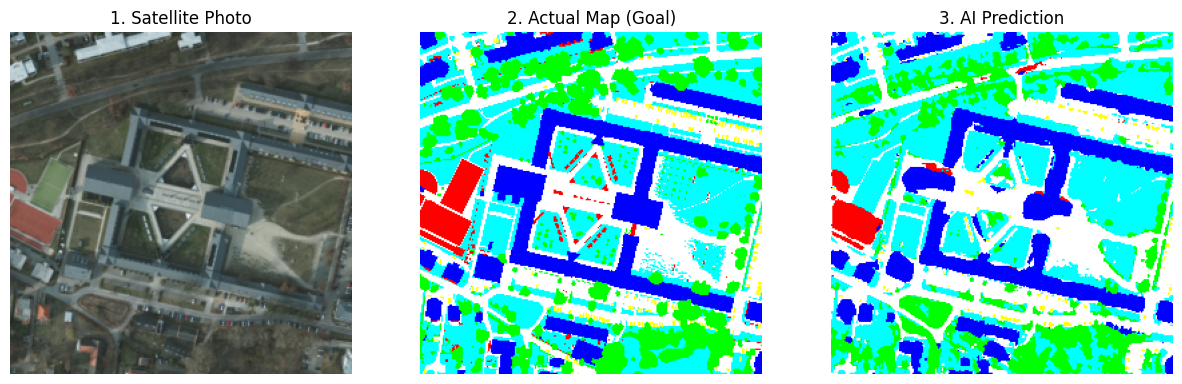

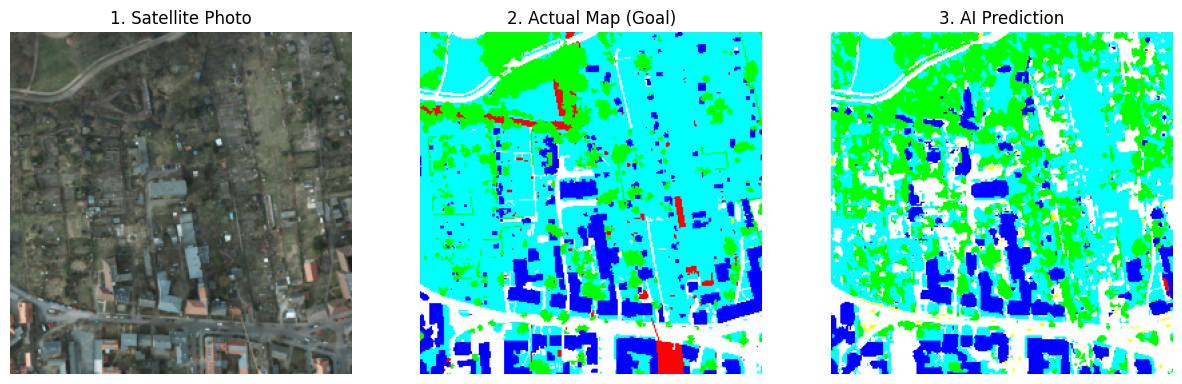

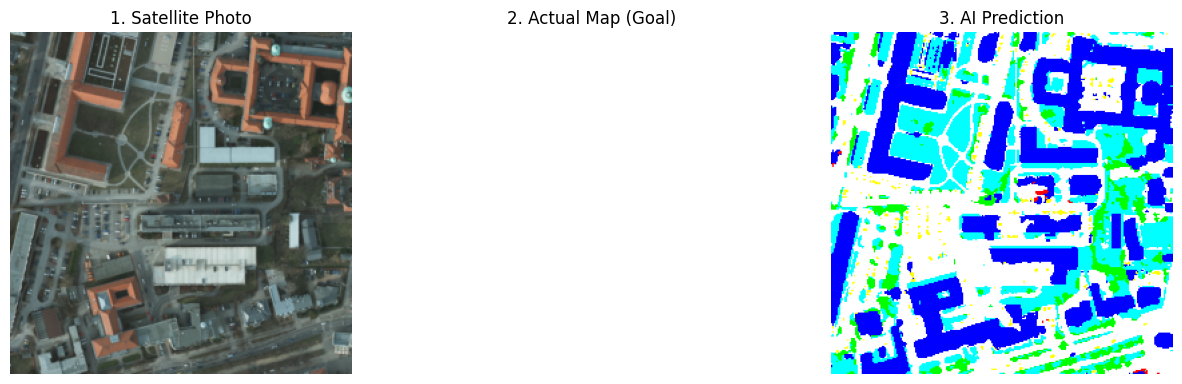

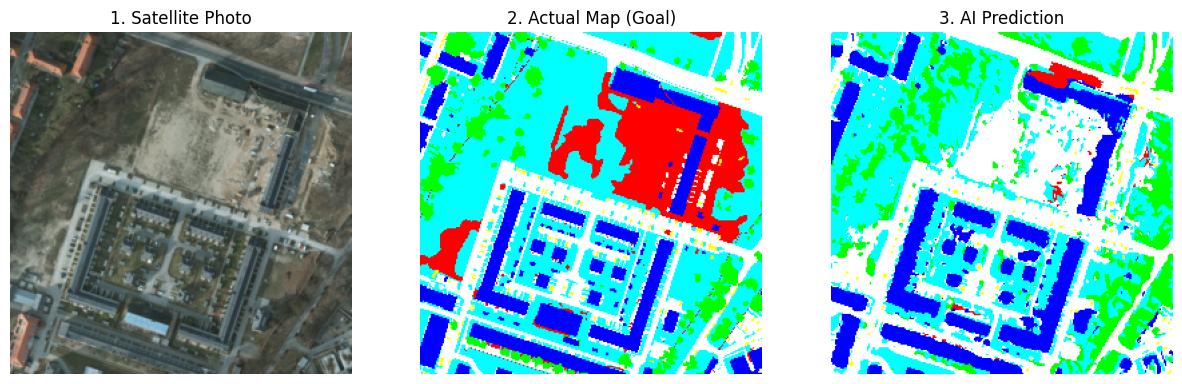

In [7]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1. SETUP COLORMAP (To turn numbers back into colors)
VOC_COLORMAP = [
    [255, 255, 255], # 0: Impervious (Roads) -> White
    [0, 0, 255],     # 1: Building -> Blue
    [0, 255, 255],   # 2: Low Veg -> Cyan
    [0, 255, 0],     # 3: Tree -> Green
    [255, 255, 0],   # 4: Car -> Yellow
    [255, 0, 0]      # 5: Clutter -> Red
]

def mask_to_rgb(mask_2d):
    h, w = mask_2d.shape
    rgb_image = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id, color in enumerate(VOC_COLORMAP):
        rgb_image[mask_2d == class_id] = color
    return rgb_image

# 2. GET PREDICTIONS
model.eval() # Set to evaluation mode
images, masks = next(iter(test_loader)) # Get a batch of test data
images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images) # Make prediction
    preds = torch.argmax(outputs, dim=1) # Get the winner class

# 3. PLOT THE RESULTS (Top 3 images)
print("Generating Visualization...")
for i in range(4):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # A. Original Photo
    img_show = images[i].cpu().permute(1, 2, 0).numpy()
    ax[0].imshow(img_show)
    ax[0].set_title("1. Satellite Photo")
    ax[0].axis('off')
    
    # B. The True Answer (Ground Truth)
    true_mask = mask_to_rgb(masks[i].cpu().numpy())
    ax[1].imshow(true_mask)
    ax[1].set_title("2. Actual Map (Goal)")
    ax[1].axis('off')
    
    # C. Your Model's Prediction
    pred_mask = mask_to_rgb(preds[i].cpu().numpy())
    ax[2].imshow(pred_mask)
    ax[2].set_title("3. AI Prediction")
    ax[2].axis('off')
    
    plt.show()

In [8]:
# Get a batch of predictions
images, masks = next(iter(test_loader))
images = images.to(DEVICE)
model.eval()
with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1) # The winner class (0-5)

# PRINT THE TRUTH
print("--- Model Prediction Statistics ---")
print(f"Unique Predicted Classes: {torch.unique(preds)}")
print(f"Most Common Class: {torch.mode(preds.view(-1)).values.item()}")

# Check the Ground Truth too (to make sure it's not all red!)
print(f"Unique Ground Truth Classes: {torch.unique(masks)}")

--- Model Prediction Statistics ---
Unique Predicted Classes: tensor([0, 1, 2, 3, 4, 5], device='cuda:0')
Most Common Class: 0
Unique Ground Truth Classes: tensor([0, 1, 2, 3, 4, 5])


Starting Training for 30 epochs with Learning Rate 0.0001...
Epoch 1/30, Loss: 1.8186
Epoch 2/30, Loss: 1.6359
Epoch 3/30, Loss: 1.5017
Epoch 4/30, Loss: 1.4097
Epoch 5/30, Loss: 1.3086
Epoch 6/30, Loss: 1.2357
Epoch 7/30, Loss: 1.2033
Epoch 8/30, Loss: 1.1758
Epoch 9/30, Loss: 1.1223
Epoch 10/30, Loss: 1.1004
Epoch 11/30, Loss: 1.0926
Epoch 12/30, Loss: 1.0525
Epoch 13/30, Loss: 1.0143
Epoch 14/30, Loss: 0.9877
Epoch 15/30, Loss: 0.9718
Epoch 16/30, Loss: 0.9653
Epoch 17/30, Loss: 0.9182
Epoch 18/30, Loss: 0.8954
Epoch 19/30, Loss: 0.8969
Epoch 20/30, Loss: 0.8532
Epoch 21/30, Loss: 0.8433
Epoch 22/30, Loss: 0.8213
Epoch 23/30, Loss: 0.7944
Epoch 24/30, Loss: 0.7715
Epoch 25/30, Loss: 0.7428
Epoch 26/30, Loss: 0.7541
Epoch 27/30, Loss: 0.7494
Epoch 28/30, Loss: 0.7070
Epoch 29/30, Loss: 0.6900
Epoch 30/30, Loss: 0.6651
✅ Training Complete!


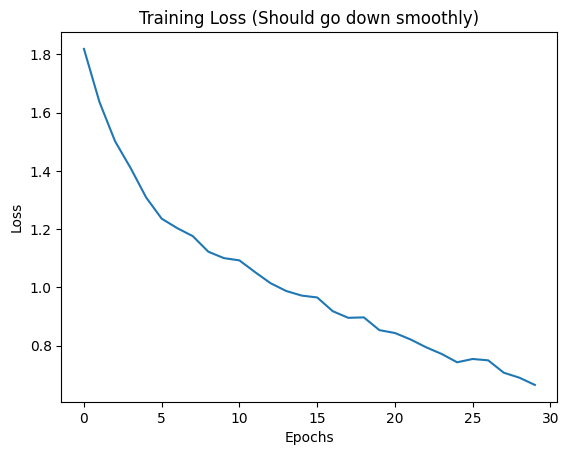

In [9]:
# 1. RESET THE MODEL (Start fresh so we don't keep the bad "Red" habits)
model = UNet(in_channels=3, out_channels=6).to(DEVICE)

# 2. USE SLOWER LEARNING RATE
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # <--- Slower!
criterion = nn.CrossEntropyLoss()

# 3. TRAIN LONGER
NUM_EPOCHS = 30 # <--- Longer!

print(f"Starting Training for {NUM_EPOCHS} epochs with Learning Rate 0.0001...")

loss_history = []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    
    for images, masks in train_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {avg_loss:.4f}")

print("✅ Training Complete!")

# 4. PLOT THE LEARNING CURVE
import matplotlib.pyplot as plt
plt.plot(loss_history)
plt.title("Training Loss (Should go down smoothly)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

--- Prediction Stats ---
Unique Classes Found: tensor([0, 1, 2, 3, 4, 5], device='cuda:0')


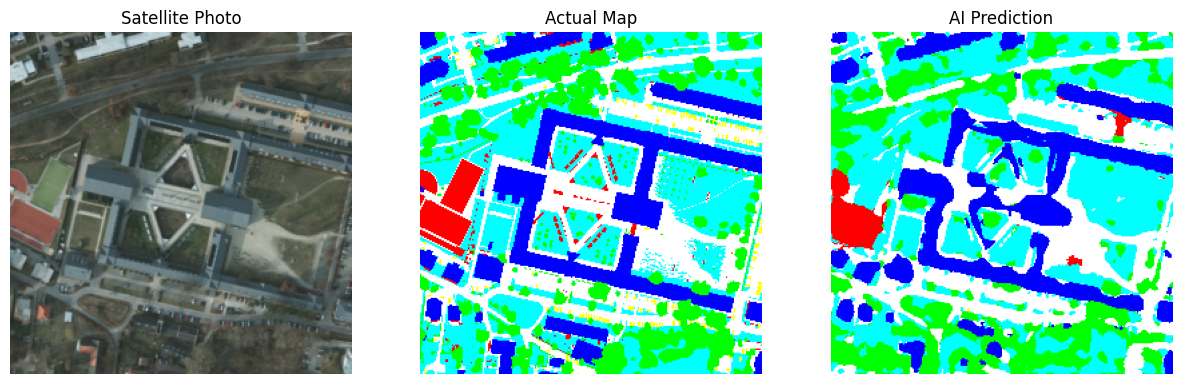

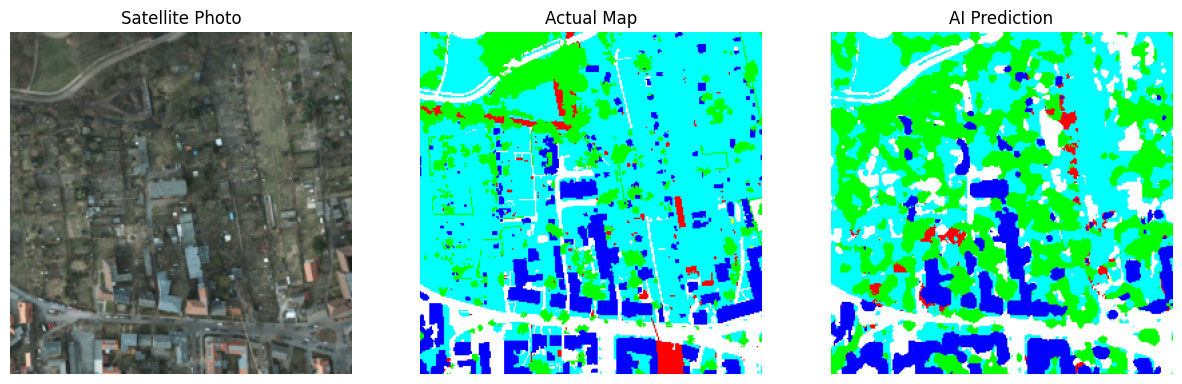

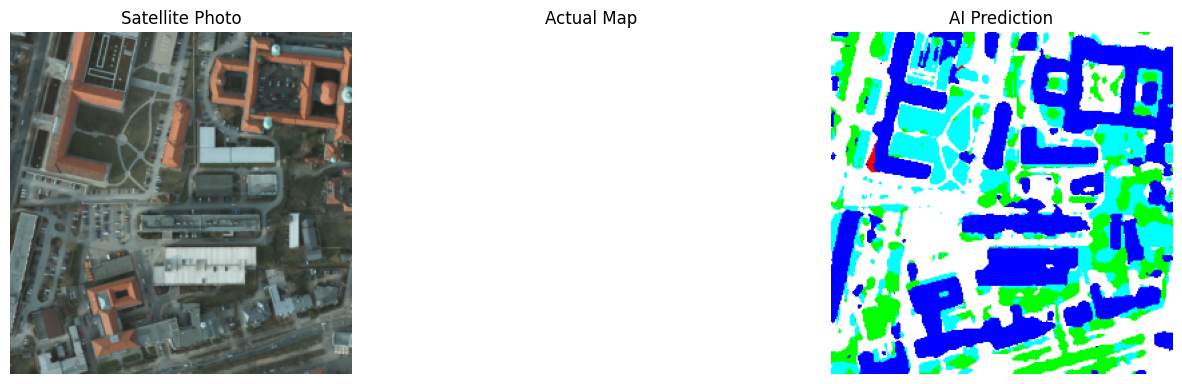

In [10]:
# --- VISUALIZATION CODE ---
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1. SETUP COLORMAP
VOC_COLORMAP = [
    [255, 255, 255], # 0: Impervious (Roads) -> White
    [0, 0, 255],     # 1: Building -> Blue
    [0, 255, 255],   # 2: Low Veg -> Cyan
    [0, 255, 0],     # 3: Tree -> Green
    [255, 255, 0],   # 4: Car -> Yellow
    [255, 0, 0]      # 5: Clutter -> Red
]

def mask_to_rgb(mask_2d):
    h, w = mask_2d.shape
    rgb_image = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id, color in enumerate(VOC_COLORMAP):
        rgb_image[mask_2d == class_id] = color
    return rgb_image

# 2. GET PREDICTIONS
model.eval()
images, masks = next(iter(test_loader))
images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

# 3. PRINT STATS (To check if "All Red" is gone)
print("--- Prediction Stats ---")
print(f"Unique Classes Found: {torch.unique(preds)}") 
# ^^^ LOOK HERE: If you see [0, 1, 3] etc, you are successful!

# 4. PLOT
for i in range(3):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original
    img_show = images[i].cpu().permute(1, 2, 0).numpy()
    ax[0].imshow(img_show)
    ax[0].set_title("Satellite Photo")
    ax[0].axis('off')
    
    # Truth
    true_mask = mask_to_rgb(masks[i].cpu().numpy())
    ax[1].imshow(true_mask)
    ax[1].set_title("Actual Map")
    ax[1].axis('off')
    
    # Prediction
    pred_mask = mask_to_rgb(preds[i].cpu().numpy())
    ax[2].imshow(pred_mask)
    ax[2].set_title("AI Prediction")
    ax[2].axis('off')
    
    plt.show()